# RAFT Training Data Exploration

This notebook provides a comprehensive exploration of the RAFT (Retrieval-Augmented Fine-Tuning) training dataset generated by `raft_datagen.py`. The primary goals are:

1. **Validate generation quality** — confirm that oracle/distractor ratios and answer formats are correct.
2. **Determine `max_new_tokens`** — by analysing the distribution of CoT answer lengths.
3. **Determine `max_seq_length`** — by analysing the distribution of full instruction (context + question) lengths.

## Dataset Overview

The RAFT dataset is stored in `data/training_data_raft/raw` as three JSONL splits:

| Split | File | Purpose |
|-------|------|---------|
| Train | `train.jsonl` | Fine-tuning examples (80 %) |
| Validation | `validation.jsonl` | In-training evaluation / early stopping (10 %) |
| Test | `test.jsonl` | Held-out evaluation (10 %) |

Each record contains:

| Field | Description |
|-------|-------------|
| `question` | A factual question derived from a source document chunk |
| `context` | Retrieved passages — either oracle plus distractors, or distractor-only passages |
| `oracle_context` | The specific chunk containing the correct answer |
| `cot_answer` | Chain-of-thought answer with `##begin_quote##` citations and a final `<ANSWER>:` tag |
| `instruction` | Fully formatted model input: `<DOCUMENT>` blocks + question |
| `type` | `"oracle"` (answer chunk present) or `"distractor"` (answer chunk withheld) |

## Notebook Sections

1. Load Dataset  
2. Dataset Balance: Oracle vs Distractor  
3. CoT Answer Length Analysis → guides `max_new_tokens`  
4. Instruction (Context) Length Analysis → guides `max_seq_length`  
5. Persist Computed Columns

## 1. Load Dataset

Load the three JSONL splits into Pandas DataFrames and verify row counts. The 80/10/10 split is produced by `raft_datagen.py` at generation time.

In [168]:
# load training data from training_data_raft
import pandas as pd
import os
dir = "./data/training_data_raft/"
train_df = pd.read_json(os.path.join(dir, "train.jsonl"), lines=True)
test_df = pd.read_json(os.path.join(dir, "test.jsonl"), lines=True)
validation_df = pd.read_json(os.path.join(dir, "validation.jsonl"), lines=True)
print(f"Number of samples: train={len(train_df)}, test={len(test_df)}")
train_df.head()

Number of samples: train=507, test=64


,id,type,question,context,oracle_context,cot_answer,instruction,cot_answer_length,instruction_length
0,seed_task_83,distractor,What ServiceNow document outlines supported sk...,"{'title': [['placeholder_title', 'placeholder_...",## Evaluate and configure AI model options on ...,### Step-by-Step Reasoning:\n\n1. **Understand...,"<DOCUMENT>Additionally, it involves disabling ...",147,440
1,seed_task_60,oracle,What does the ServiceNow Access Control plugin...,"{'title': [['placeholder_title', 'placeholder_...",## Activate the ServiceNow Access Control (SNA...,Step-by-step reasoning:\n\n1. To answer the qu...,<DOCUMENT>### Manage the organization’s mobile...,149,428
2,seed_task_41,oracle,What should password policies address in both ...,"{'title': [['placeholder_title', 'placeholder_...",#### Configure and enforce strong password pol...,Step-by-step reasoning:\n\n1. To answer the qu...,<DOCUMENT>#### Configure and enforce strong pa...,269,485
3,seed_task_72,oracle,Does ServiceNow provide free encryption option...,"{'title': [['placeholder_title', 'placeholder_...",```markdown\n# Data at rest\n\n## Customer res...,### Step-by-Step Reasoning:\n\n1. The question...,<DOCUMENT>```markdown\n# Email security\n\n## ...,151,494
4,seed_task_126,oracle,Where can ServiceNow security contacts be upda...,"{'title': [['placeholder_title', 'placeholder_...",#### Ensure security communications from Servi...,### Step-by-Step Reasoning:\n\n1. The question...,<DOCUMENT>ServiceNow publishes Security Adviso...,142,428


## 2. Dataset Balance: Oracle vs Distractor

Each sample is labelled `"oracle"` (the correct chunk is present in the retrieved context) or `"distractor"` (the oracle chunk is withheld). Following the RAFT paper, roughly **80 %** of samples include the oracle with distractors and **20 %** contain only distractors; both are still trained toward the oracle-derived answer `A*`.

Verify that the generation script produced the expected balance across all three splits.

In [169]:
print(train_df["type"].value_counts())
print(test_df["type"].value_counts())
print(validation_df["type"].value_counts())

# % of examples where the oracle chunk is included in the context
print("Train oracle chunk inclusion rate:", (train_df["type"] == "oracle").mean())
print("Test oracle chunk inclusion rate:", (test_df["type"] == "oracle").mean())
print("Validation oracle chunk inclusion rate:", (validation_df["type"] == "oracle").mean())

type
oracle        400
distractor    107
Name: count, dtype: int64
type
oracle        55
distractor     9
Name: count, dtype: int64
type
oracle        48
distractor    15
Name: count, dtype: int64
Train oracle chunk inclusion rate: 0.7889546351084813
Test oracle chunk inclusion rate: 0.859375
Validation oracle chunk inclusion rate: 0.7619047619047619


### 2.1 Sample Oracle Example

Inspect a single oracle-type record to verify the CoT answer format. A well-formed answer should:
- Cite evidence with `##begin_quote##...##end_quote##` markers drawn verbatim from the context
- End with a concise `<ANSWER>: ...` tag containing the final response

In [170]:
sample_oracle = train_df[train_df["type"]== "oracle"].iloc[0]
print("Question:", sample_oracle["question"])
print("COT Answer:", sample_oracle["cot_answer"])

Question: What does the ServiceNow Access Control plugin allow customers to control?
COT Answer: Step-by-step reasoning:

1. To answer the question, I need to determine what the ServiceNow Access Control (SNAC) plugin allows customers to control. 
2. I will look for relevant information in the context that describes the functionality or purpose of the SNAC plugin.
3. In the context, I find the following sentence: ##begin_quote## Customers may choose to activate the [ServiceNow access control plugin](#), which enables customers to control which ServiceNow customer service and support employees can access their instance, and when. ##end_quote##. This sentence directly explains the control provided by the plugin.
4. Additionally, the context mentions: ##begin_quote## Once this control is enabled, ServiceNow personnel must request ad-hoc, time-bound access. ##end_quote##. This further clarifies that the plugin enforces restrictions on access by ServiceNow personnel.

Final Answer: <ANSWER>

### 2.2 Sample Distractor Example

In a distractor example the oracle chunk is **absent** from the context. RAFT still trains the model to produce the oracle-derived answer `A*`, which mirrors the paper's `Q + D_1 ... D_k -> A*` examples.

In [171]:
sample_distractor = train_df[train_df["type"]== "distractor"].iloc[0]
print("Question:", sample_distractor["question"])

print("Context sentences:\n\n")
print("="*50)
for sentence in sample_distractor["context"]["sentences"][0]:
    print("-", sentence)

print("COT Answer:", sample_distractor["cot_answer"])

Question: What ServiceNow document outlines supported skills and agents for LLMs?
Context sentences:


- Additionally, it involves disabling local logins to enhance security. By default, MFA is enabled for all local logins, and customers must manage exceptions and monitor to ensure this default setting is maintained. The authentication mechanism plays a crucial role by verifying the identity of users accessing a ServiceNow instance and subsequently authorizing them to access features that correspond to their role or job function.

---

### Best practices

#### Change default passwords
ServiceNow instances come with certain built-in accounts such as “admin,” “ITIL,” and “employee” which are provisioned with default passwords, unique to the instance. Customer admins should change all default passwords for built-in accounts immediately upon instance creation, ensuring that each new password meets your organization’s complexity and strength requirements.
- ### RECOVER 43  
Business continu

## 3. CoT Answer Length Analysis

Understanding the distribution of CoT answer lengths (measured in whitespace-delimited words) is critical for setting `max_new_tokens` during fine-tuning and inference.

**Guidance:** a reasonable `max_new_tokens` should cover at least the **95th percentile** of the answer word count. Multiply by ~1.3 to convert words to sub-word tokens.

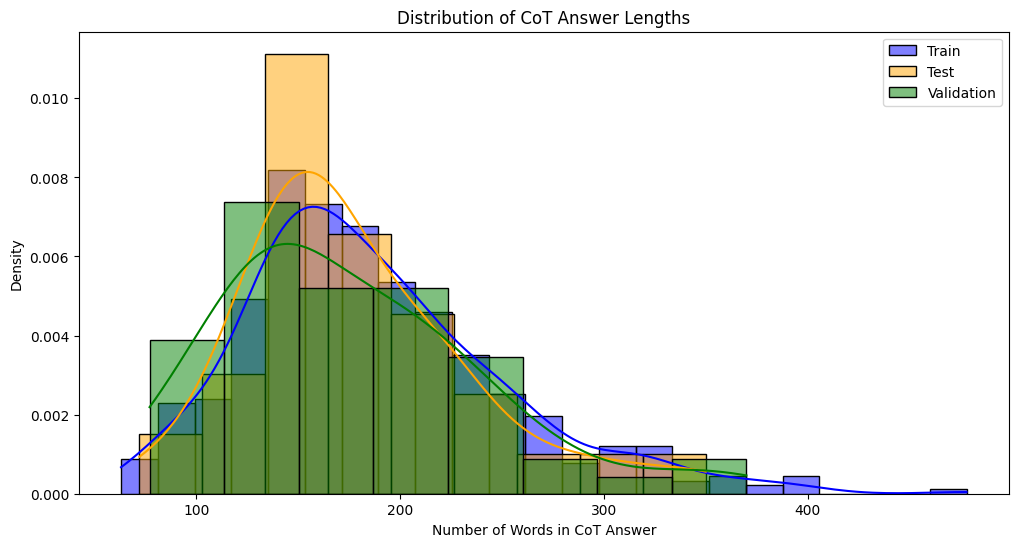

In [172]:
import matplotlib.pyplot as plt
import seaborn as sns

train_df["cot_answer_length"] = train_df["cot_answer"].apply(lambda x: len(x.split()))
test_df["cot_answer_length"] = test_df["cot_answer"].apply(lambda x: len(x.split()))
validation_df["cot_answer_length"] = validation_df["cot_answer"].apply(lambda x: len(x.split()))
plt.figure(figsize=(12, 6))
sns.histplot(train_df["cot_answer_length"], color="blue", label="Train", kde=True, stat="density")
sns.histplot(test_df["cot_answer_length"], color="orange", label="Test", kde=True, stat="density")
sns.histplot(validation_df["cot_answer_length"], color="green", label="Validation", kde=True, stat="density")
plt.title("Distribution of CoT Answer Lengths")
plt.xlabel("Number of Words in CoT Answer")
plt.legend()
plt.show()

### 3.1 Percentile Statistics

Compute descriptive statistics with key percentiles to identify a safe `max_new_tokens` cutoff.

In [173]:
# order by length and look at percentiles for train, test, and validation sets
print("Train CoT answer length percentiles:")
print(train_df["cot_answer_length"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
print("\nTest CoT answer length percentiles:")
print(test_df["cot_answer_length"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
print("\nValidation CoT answer length percentiles:")
print(validation_df["cot_answer_length"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

Train CoT answer length percentiles:
count    507.000000
mean     186.806706
std       63.914980
min       63.000000
25%      143.500000
50%      175.000000
75%      218.000000
90%      269.400000
95%      314.000000
99%      374.820000
max      478.000000
Name: cot_answer_length, dtype: float64

Test CoT answer length percentiles:
count     64.000000
mean     178.140625
std       56.120298
min       72.000000
25%      142.250000
50%      165.000000
75%      210.000000
90%      244.500000
95%      293.250000
99%      343.070000
max      350.000000
Name: cot_answer_length, dtype: float64

Validation CoT answer length percentiles:
count     63.000000
mean     175.809524
std       63.949036
min       77.000000
25%      133.000000
50%      162.000000
75%      212.000000
90%      256.800000
95%      283.000000
99%      356.360000
max      370.000000
Name: cot_answer_length, dtype: float64


## 4. Instruction (Context) Length Analysis

The `instruction` field is the full model input: multiple `<DOCUMENT>` blocks followed by the question. Depending on `type`, those blocks contain either oracle plus distractors or distractors only. Its word-count distribution determines a safe value for `max_seq_length` in the fine-tuning configuration.

> **Important:** samples longer than `max_seq_length` tokens are silently **right-truncated** by the tokeniser, which can clip the question and cause the model to learn from malformed examples.

**Guidance:** set `max_seq_length` ≥ 99th percentile of instruction word count × 1.3 (words-to-tokens expansion factor).

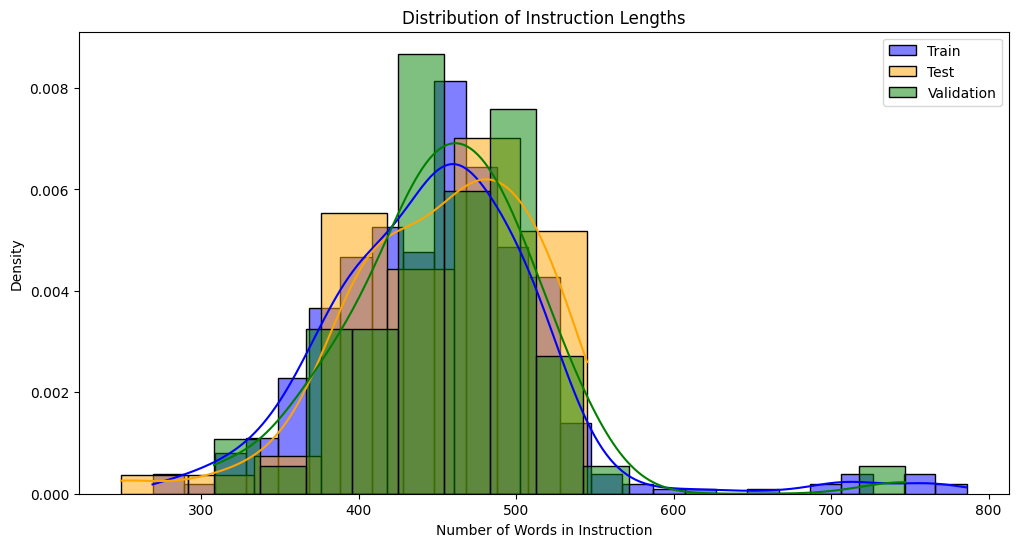

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns

train_df["instruction_length"] = train_df["instruction"].apply(lambda x: len(x.split()))
test_df["instruction_length"] = test_df["instruction"].apply(lambda x: len(x.split()))
validation_df["instruction_length"] = validation_df["instruction"].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 6))
sns.histplot(train_df["instruction_length"], color="blue", label="Train", kde=True, stat="density")
sns.histplot(test_df["instruction_length"], color="orange", label="Test", kde=True, stat="density")
sns.histplot(validation_df["instruction_length"], color="green", label="Validation", kde=True, stat="density")
plt.title("Distribution of Instruction Lengths")
plt.xlabel("Number of Words in Instruction")
plt.legend()
plt.show()


### 4.1 Percentile Statistics

Compute descriptive statistics to determine a safe `max_seq_length`. Pay attention to the 95th and 99th percentiles — multiply by ~1.3 to estimate sub-word token counts.

In [175]:
print("Train instruction length percentiles:")
print(train_df["instruction_length"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
print("\nTest instruction length percentiles:")
print(test_df["instruction_length"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
print("\nValidation instruction length percentiles:")
print(validation_df["instruction_length"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

# Estimate token count at the 99th percentile (words × 1.3 expansion factor)
p99_words = train_df["instruction_length"].quantile(0.99)
print(f"\nTrain 99th percentile: {p99_words:.0f} words ≈ {p99_words * 1.3:.0f} tokens")
print("Recommended max_seq_length:", int(p99_words * 1.3 * 1.1 / 128 + 1) * 128, "(rounded up to nearest 128)")


Train instruction length percentiles:
count    507.000000
mean     451.349112
std       72.024140
min      269.000000
25%      406.500000
50%      452.000000
75%      487.500000
90%      517.000000
95%      537.800000
99%      745.200000
max      786.000000
Name: instruction_length, dtype: float64

Test instruction length percentiles:
count     64.000000
mean     453.421875
std       58.957559
min      249.000000
25%      412.250000
50%      461.500000
75%      497.750000
90%      520.100000
95%      530.850000
99%      543.110000
max      545.000000
Name: instruction_length, dtype: float64

Validation instruction length percentiles:
count     63.000000
mean     455.746032
std       63.691284
min      308.000000
25%      427.000000
50%      455.000000
75%      488.500000
90%      521.800000
95%      531.900000
99%      620.520000
max      747.000000
Name: instruction_length, dtype: float64

Train 99th percentile: 745 words ≈ 969 tokens
Recommended max_seq_length: 1152 (rounded up to ne

## 5. Persist Computed Columns

Write the enriched DataFrames — now including `cot_answer_length` and `instruction_length` — back to the source JSONL files. These columns are useful for downstream filtering (e.g., dropping records that exceed the training context window before fine-tuning).

In [176]:
# Update JSONL files to include instruction length and cot answer length
dir = "./data/training_data_raft"
# make sure the directory exists
os.makedirs(dir, exist_ok=True)
train_df.to_json(os.path.join(dir, "train.jsonl"), orient="records", lines=True)
test_df.to_json(os.path.join(dir, "test.jsonl"), orient="records", lines=True)
validation_df.to_json(os.path.join(dir, "validation.jsonl"), orient="records", lines=True)

In [177]:
MAX_NEW_TOKENS = train_df["cot_answer_length"].max() # 512
MAX_SEQ_LEN = train_df["instruction_length"].max() # around 1600

# Based on the analysis, we can set max_new_tokens to 512 and max_seq_length to around 2048 (to accommodate the longest instructions and answers with some buffer).
print(f"Recommended max_new_tokens: {MAX_NEW_TOKENS}")
print(f"Recommended max_seq_length: {int(MAX_SEQ_LEN * 1.3 * 1.1 / 128 + 1) * 128} (rounded up to nearest 128)")

Recommended max_new_tokens: 478
Recommended max_seq_length: 1152 (rounded up to nearest 128)


## Summary 

Based on the analysis above, the following hyperparameters are suggested for the fine-tuning notebook (`raft-finetuning-slm.ipynb`):

| Parameter | Suggested Value | Rationale |
|-----------|-----------------|-----------|
| `max_new_tokens` | 256 – 512 | Covers ≥ 95th percentile of CoT answer word counts |
| `max_seq_length` | 1024 – 2048 | Covers ≥ 99th percentile of instruction word counts (× 1.3 token expansion) |
| Expected oracle ratio | ~ 0.80 | Verified in Section 2 |

# Final Evaluation Results

The final evaluation results exploration has been split into [final_results_exploration.ipynb](final_results_exploration.ipynb).